#Gradient Boosting


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.calibration import calibration_curve

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    brier_score_loss,
    confusion_matrix,
    classification_report,
    roc_curve,
    RocCurveDisplay,
    ConfusionMatrixDisplay
)

## 1. Carga y preparación

In [7]:
DATA_FILE = Path("/content/sample_data/cardio_train.csv")
df = pd.read_csv(DATA_FILE, sep=";")

valid_mask = (
    df["height"].between(120, 220)
    & df["weight"].between(30, 200)
    & df["ap_hi"].between(70, 250)
    & df["ap_lo"].between(40, 150)
    & (df["ap_hi"] > df["ap_lo"])
)

df = df.loc[valid_mask].copy()

df["age_years"] = df["age"] / 365.25
df["bmi"] = df["weight"] / ((df["height"] / 100) ** 2)

df_model = df.drop(columns=["id", "age"])

X = df_model.drop(columns=["cardio", "cholesterol", "gluc"])
y = df_model["cardio"]

print(X.shape, y.shape)

FileNotFoundError: [Errno 2] No such file or directory: '\\content\\sample_data\\cardio_train.csv'

## 2. Train / Validation / Test

In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

for name, X_part, y_part in [
    ("Train", X_train, y_train),
    ("Validation", X_val, y_val),
    ("Test", X_test, y_test)
]:
    print(
        f"{name}: {len(X_part):,} observaciones | "
        f"cardio=1: {y_part.mean()*100:.2f}%"
    )

Train: 48,027 observaciones | cardio=1: 49.47%
Validation: 10,291 observaciones | cardio=1: 49.47%
Test: 10,292 observaciones | cardio=1: 49.47%


## 3. Preprocesador

In [ ]:
continuous_features = [
    "height",
    "weight",
    "ap_hi",
    "ap_lo",
    "age_years",
    "bmi"
]

ordinal_features = []

binary_features = [
    "smoke",
    "alco",
    "active"
]

categorical_features = [
    "gender"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "continuous",
            "passthrough",
            continuous_features
        ),
        (
            "gender",
            OneHotEncoder(
                drop=None,
                handle_unknown="ignore"
            ),
            categorical_features
        ),
        (
            "ordinal",
            "passthrough",
            ordinal_features
        ),
        (
            "binary",
            "passthrough",
            binary_features
        )
    ]
)

## 4. Crear Pipeline y modelo

El `Pipeline` conecta automáticamente:

1. preprocesamiento;
2. transformación;
3. entrenamiento.

Así evitamos *data leakage*.

In [ ]:
gradient_boosting_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", gradient_boosting_model)
    ]
)

pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('continuous', 'passthrough',
                                                  ['height', 'weight', 'ap_hi',
                                                   'ap_lo', 'age_years',
                                                   'bmi']),
                                                 ('gender',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender']),
                                                 ('ordinal', 'passthrough', []),
                                                 ('binary', 'passthrough',
                                                  ['smoke', 'alco',
                                                   'active'])])),
                ('model', GradientBoostingClassifier(random_state=42))])

## 5. Entrenar con Train

In [ ]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('continuous', 'passthrough',
                                                  ['height', 'weight', 'ap_hi',
                                                   'ap_lo', 'age_years',
                                                   'bmi']),
                                                 ('gender',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender']),
                                                 ('ordinal', 'passthrough', []),
                                                 ('binary', 'passthrough',
                                                  ['smoke', 'alco',
                                                   'active'])])),
                ('model', GradientBoostingClassifier(random_state=42))])

## 6. Predicciones sobre Validation

In [ ]:
y_val_pred = pipeline.predict(X_val)
y_val_proba = pipeline.predict_proba(X_val)[:, 1]

print("Clases predichas:")
print(y_val_pred[:10])

print("\nProbabilidades cardio=1:")
print(y_val_proba[:10])

Clases predichas:
[1 1 1 0 1 0 1 0 0 1]

Probabilidades cardio=1:
[0.63552119 0.85457392 0.62286754 0.34456354 0.59390782 0.47955545
 0.82230905 0.30769062 0.11520129 0.80866675]


`predict()` devuelve 0/1.

`predict_proba()` devuelve dos probabilidades por fila:

`P(cardio=0)` y `P(cardio=1)`.

Por eso `[:, 1]` selecciona la probabilidad de la clase positiva.

## 7 NUEVO. Evaluación de calibración

Brier Score modelo:   0.1866
Brier Score baseline: 0.2500


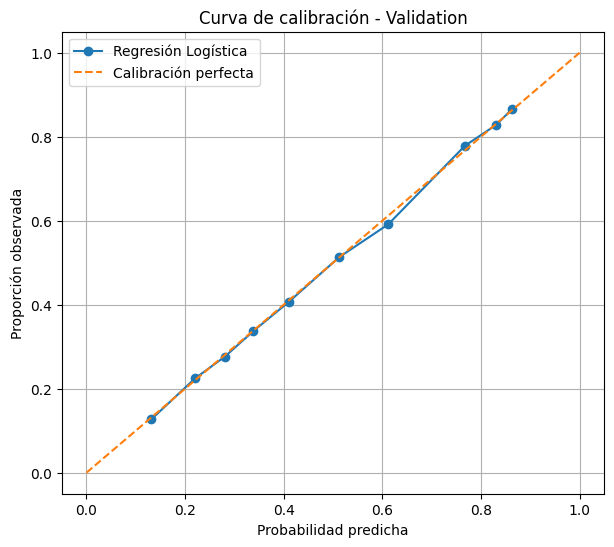

In [ ]:
prob_true, prob_pred = calibration_curve(
    y_val,
    y_val_proba,
    n_bins=10,
    strategy="quantile"
)

brier = brier_score_loss(
    y_val,
    y_val_proba
)

# Modelo de referencia:
# todos reciben como probabilidad la prevalencia aprendida en Train
baseline_proba = np.full(
    len(y_val),
    y_train.mean()
)

brier_baseline = brier_score_loss(
    y_val,
    baseline_proba
)

print(f"Brier Score modelo:   {brier:.4f}")
print(f"Brier Score baseline: {brier_baseline:.4f}")

plt.figure(figsize=(7, 6))

plt.plot(
    prob_pred,
    prob_true,
    marker="o",
    label="Gradient Boosting"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Calibración perfecta"
)

plt.xlabel("Probabilidad predicha")
plt.ylabel("Proporción observada")
plt.title("Curva de calibración - Validation")
plt.legend()
plt.grid()

plt.show()

## 7. Métricas

In [ ]:
accuracy = accuracy_score(y_val, y_val_pred)
precision = precision_score(y_val, y_val_pred)
recall = recall_score(y_val, y_val_pred)
f1 = f1_score(y_val, y_val_pred)
roc_auc = roc_auc_score(y_val, y_val_proba)

metrics_df = pd.DataFrame({
    "Métrica": [
        "Accuracy",
        "Precision",
        "Recall / Sensitivity",
        "F1-score",
        "ROC-AUC"
    ],
    "Valor": [accuracy, precision, recall, f1, roc_auc]
})

metrics_df.round(4)

,Métrica,Valor
0,Accuracy,0.7240
1,Precision,0.7363
2,Recall / Sensitivity,0.6889
3,F1-score,0.7118
4,ROC-AUC,0.7876


- **Accuracy:** proporción total de predicciones correctas.
- **Precision:** de los predichos positivos, cuántos son realmente positivos.
- **Recall:** de los positivos reales, cuántos detectamos.
- **F1:** balance entre Precision y Recall.
- **ROC-AUC:** capacidad de discriminación a través de distintos umbrales.

## 8. Matriz de confusión

TN: 3944
FP: 1256
FN: 1584
TP: 3507


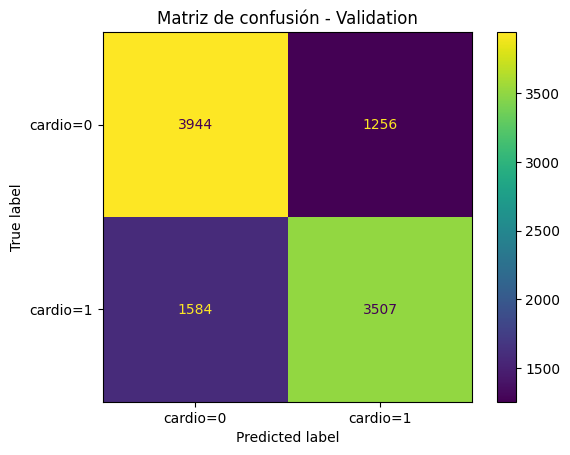

In [ ]:
cm = confusion_matrix(y_val, y_val_pred)

tn, fp, fn, tp = cm.ravel()

print("TN:", tn)
print("FP:", fp)
print("FN:", fn)
print("TP:", tp)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["cardio=0", "cardio=1"]
).plot()

plt.title("Matriz de confusión - Validation")
plt.show()

## 9. Classification report

In [ ]:
print(
    classification_report(
        y_val,
        y_val_pred,
        target_names=["cardio=0", "cardio=1"],
        digits=4
    )
)

              precision    recall  f1-score   support

    cardio=0     0.7135    0.7585    0.7353      5200
    cardio=1     0.7363    0.6889    0.7118      5091

    accuracy                         0.7240     10291
   macro avg     0.7249    0.7237    0.7235     10291
weighted avg     0.7248    0.7240    0.7237     10291



## 10. Curva ROC

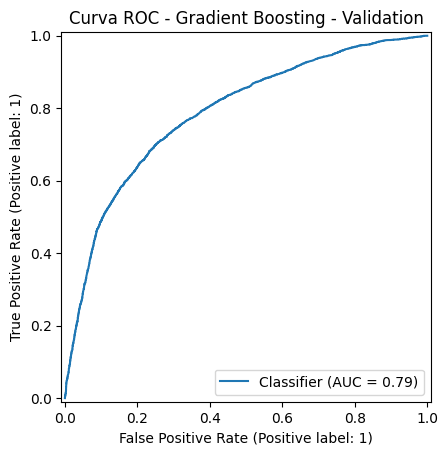

In [ ]:
RocCurveDisplay.from_predictions(
    y_val,
    y_val_proba
)

plt.title("Curva ROC - Gradient Boosting - Validation")
plt.show()

## 11. Importancia de características

In [ ]:
feature_names = (
    pipeline
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

feature_importances = (
    pipeline
    .named_steps["model"]
    .feature_importances_
)

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": feature_importances
}).sort_values(
    "importance",
    ascending=False
)

importance_df

,feature,importance
2,continuous__ap_hi,0.779281
4,continuous__age_years,0.153716
5,continuous__bmi,0.023645
3,continuous__ap_lo,0.018116
1,continuous__weight,0.009895
10,binary__active,0.006878
0,continuous__height,0.002787
8,binary__smoke,0.002596
9,binary__alco,0.001796
6,gender__gender_1,0.001139


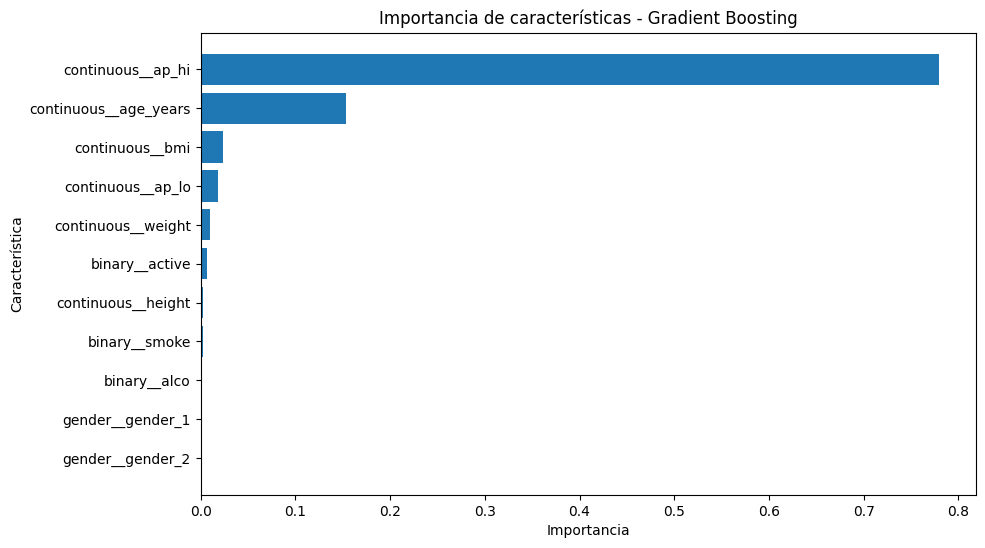

In [ ]:
plt.figure(figsize=(10, 6))

top_features = importance_df.head(15).sort_values(
    "importance"
)

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.xlabel("Importancia")
plt.ylabel("Característica")
plt.title(
    "Importancia de características - Gradient Boosting"
)

plt.show()

Coeficiente positivo: aumenta el `log-odds` estimado de `cardio=1`.

Coeficiente negativo: lo reduce, manteniendo las demás variables constantes.

Esto no implica causalidad.

# 12. Siguiente paso

Este es nuestro **baseline**. Todavía no usamos Test para seleccionar el modelo.

Después podremos comparar contra Decision Tree, Random Forest y otros modelos usando Validation.